### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
from wordcloud import WordCloud

In [5]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [6]:
from transformers import BertTokenizerFast, AutoModel

In [7]:
import torch
from torch import nn, utils, optim

### Step 2: Constant

In [8]:
DATA_FILE = './data/sentiment_train.csv'
PADDING_LEN = 22
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Step 3: Load Data

In [9]:
df = pd.read_csv(DATA_FILE)

In [10]:
df.shape

(5668, 2)

In [11]:
df.head()

,sentence,label
0,Ok brokeback mountain is such a horrible movie.,0
1,Brokeback Mountain was so awesome.,1
2,friday hung out with kelsie and we went and sa...,0
3,I am going to start reading the Harry Potter s...,1
4,"Is it just me, or does Harry Potter suck?...",0


### Step 4: Exploaring Data

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,5668.0,0.565279,0.495764,0.0,0.0,1.0,1.0,1.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5668 entries, 0 to 5667
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  5668 non-null   object
 1   label     5668 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 88.7+ KB


In [14]:
features_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum()/len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [15]:
features_info

,null,null(%),unique,type
sentence,0,0.0,1156,object
label,0,0.0,2,int64


#### Feature Distribution

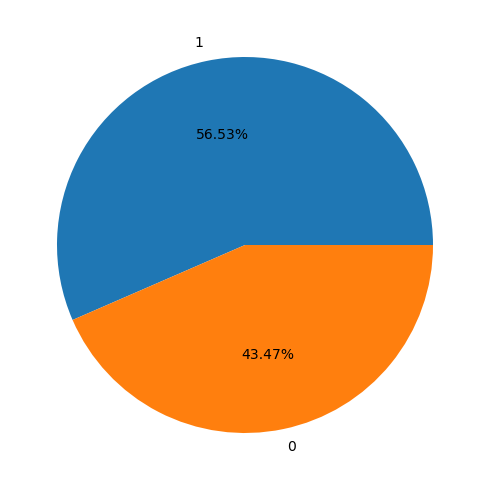

In [16]:
temp = df['label'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

### Step 5: Preparing Data

#### String Lower 

In [17]:
df['sentence'] = df['sentence'].str.lower()

#### Punctuations Removal

In [18]:
def remove_punctuations(text):
    temp = str.maketrans('', '', string.punctuation)
    return text.translate(temp)

In [19]:
df['sentence'] = df['sentence'].map(remove_punctuations)

#### Stopwords Removal and Lemmatization

In [20]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

In [21]:
df['sentence'] = df['sentence'].map(preprocess_text)

#### Plot Word Cloud

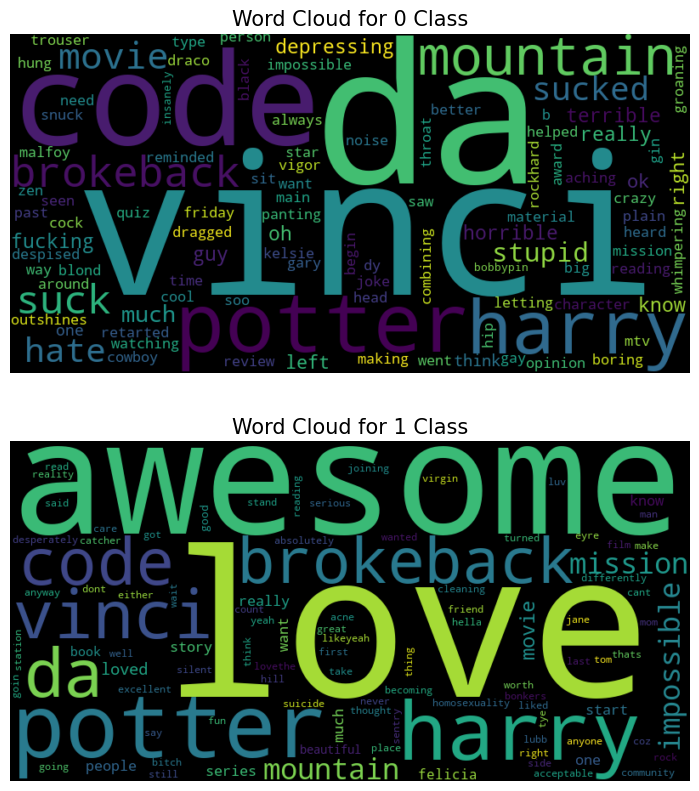

In [22]:
plt.figure(figsize=(10, 15))
for i in range(2):
    temp = df[df['label']==i]
    corpus = " ".join(temp['sentence'])
    wc = WordCloud(
        max_words=100, 
        width=800, 
        height=400,
        collocations=False
    ).generate(corpus)
    plt.subplot(3, 1, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {i} Class", fontsize=15)

#### Split Data

In [23]:
features = df['sentence']
targets = df['label']

In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    targets,
    test_size=0.4,
    random_state=42,
    stratify=targets
)

In [25]:
X_value, X_test, y_value, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

#### Plot Sentence Lenght

In [26]:
temp = X_train.str.split().str.len()

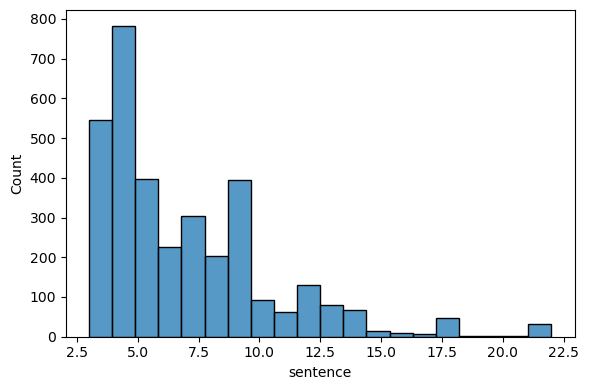

In [27]:
plt.figure(figsize=(6, 4))
sns.histplot(temp, bins=20)
plt.tight_layout()

#### Tokenization and Padding

In [28]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

In [29]:
def tokenizing(X, y):
    tokens = tokenizer(
        X.to_list(),
        max_length=PADDING_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
        return_attention_mask=True
    )
    seqs = tokens['input_ids']
    masks = tokens['attention_mask']
    labels = torch.Tensor(y.to_list()).long()
    return seqs, masks, labels

In [30]:
train_seqs, train_masks, train_labels = tokenizing(X_train, y_train)
value_seqs, value_masks, value_labels = tokenizing(X_value, y_value)
test_seqs, test_masks, test_labels = tokenizing(X_test, y_test)

#### Build Dataset

In [47]:
train_data = utils.data.TensorDataset(train_seqs, train_masks, train_labels)
value_data = utils.data.TensorDataset(value_seqs, value_masks, value_labels)
test_data = utils.data.TensorDataset(test_seqs, test_masks, test_labels)

In [32]:
train_loader = utils.data.DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [48]:
value_loader = utils.data.DataLoader(
    value_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [49]:
test_loader = utils.data.DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [37]:
for step, batch in enumerate(train_loader):
    input_ids, attention_mask, labels = batch
    print(step, ':', input_ids.shape, attention_mask.shape, labels.shape)
    break

0 : torch.Size([32, 22]) torch.Size([32, 22]) torch.Size([32])


### Step 6: Model Development

#### Build Model

In [38]:
bert = AutoModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
bert.requires_grad_(False)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [40]:
class BERT_architecture(nn.Module):
    def __init__(self, bert):
        super(BERT_architecture, self).__init__()
        self. bert = bert
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 2)
        self.softmax = nn.LogSoftmax(dim=1)
    def forward(self, seq, mask):
        _, cls_hs = self.bert(seq, attention_mask=mask, return_dict=False)
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

In [41]:
model = BERT_architecture(bert)

In [42]:
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

In [43]:
criterion = nn.NLLLoss()

In [44]:
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    verbose=False
)

#### Train Model

In [45]:
def run(model, dataloader, criterion, optimizer=None, device='cpu', is_train=True, out_preds=False):
    if is_train:
        model.train()
    else:
        model.eval()
        
    total_loss, total_acc = 0, 0
    total_num = 0
    if out_preds:
        total_preds = list()

    for batch in dataloader:
        batch = [r.to(device) for r in batch]
        seqs, masks, labels = batch

        if is_train:
            if optimizer is None:
                raise NotImplementedError("if is_train is True, optimizer shouldn't be None")
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            preds = model(seqs, masks) 
            loss = criterion(preds, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * seqs.size(0)
        preds = torch.argmax(torch.exp(preds), dim=1)
        total_acc += (preds == labels).sum().item()
        total_num += seqs.size(0)
        if out_preds:
            total_preds.append(preds.detach().cpu())
      
    avg_loss = total_loss / total_num
    avg_acc = total_acc / total_num
    if out_preds:
        total_preds = torch.cat(total_preds, dim=0)
        return avg_loss, avg_acc, total_preds
    return avg_loss, avg_acc

In [46]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, device='cpu', num_epochs=5, patience=10):
    best_val_acc = 0.0
    no_improve_count = 0
    best_model_state = model.state_dict()
    history = {
        'loss': list(),
        'val_loss': list(),
        'acc': list(),
        'val_acc': list()
    }
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        print("-" * 30)
        # 训练
        train_loss, train_acc = run(model, train_loader, criterion, optimizer, device, is_train=True)
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        history['loss'].append(train_loss)
        history['acc'].append(train_acc)
        
        # 验证
        val_loss, val_acc = run(model, val_loader, criterion, device, is_train=False)
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # 调整学习率
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print(f"EarlyStopping triggered. No improvement in {patience} epochs.")
            break
            
    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")
    # 加载最佳模型
    model.load_state_dict(best_model_state)
    return history

In [50]:
history = train_model(model, train_loader, value_loader, criterion, optimizer, lr_scheduler, DEVICE, num_epochs=50, patience=10)


Epoch 1/50
------------------------------
Train Loss: 0.6861, Train Acc: 0.5582
Val Loss: 0.6754, Val Acc: 0.5653

Epoch 2/50
------------------------------
Train Loss: 0.6761, Train Acc: 0.5774
Val Loss: 0.6640, Val Acc: 0.5653

Epoch 3/50
------------------------------
Train Loss: 0.6697, Train Acc: 0.5853
Val Loss: 0.6537, Val Acc: 0.5758

Epoch 4/50
------------------------------
Train Loss: 0.6601, Train Acc: 0.6000
Val Loss: 0.6430, Val Acc: 0.5829

Epoch 5/50
------------------------------
Train Loss: 0.6518, Train Acc: 0.6188
Val Loss: 0.6336, Val Acc: 0.6146

Epoch 6/50
------------------------------
Train Loss: 0.6457, Train Acc: 0.6312
Val Loss: 0.6252, Val Acc: 0.6129

Epoch 7/50
------------------------------
Train Loss: 0.6411, Train Acc: 0.6326
Val Loss: 0.6146, Val Acc: 0.6825

Epoch 8/50
------------------------------
Train Loss: 0.6338, Train Acc: 0.6459
Val Loss: 0.6071, Val Acc: 0.6649

Epoch 9/50
------------------------------
Train Loss: 0.6302, Train Acc: 0.6506

In [63]:
train_color = "#2c3e50"
val_color = "#e74c3c"

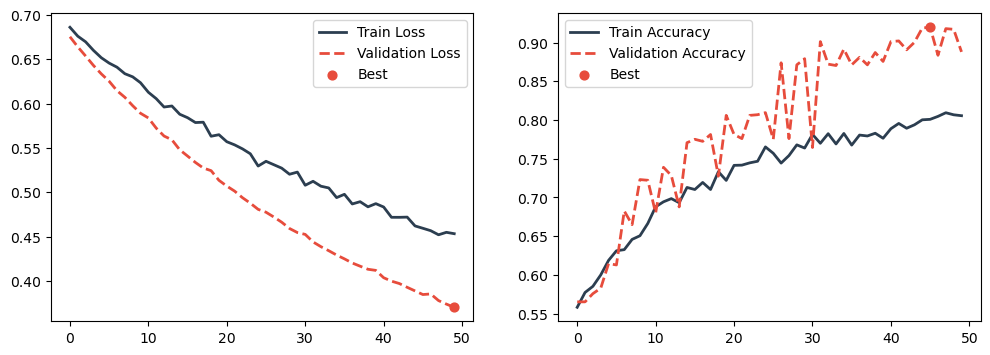

In [67]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.lineplot(history['loss'], label='Train Loss', color=train_color, linewidth=2)
sns.lineplot(history['val_loss'], label='Validation Loss', color=val_color, linewidth=2, linestyle='--')
best_epoch = history['val_loss'].index(min(history['val_loss']))
plt.scatter(best_epoch, history['val_loss'][best_epoch], s=40, label='Best', color=val_color)
plt.legend()
plt.subplot(1, 2, 2)
sns.lineplot(history['acc'], label='Train Accuracy', color=train_color, linewidth=2)
sns.lineplot(history['val_acc'], label='Validation Accuracy', color=val_color, linewidth=2, linestyle='--')
best_epoch = history['val_acc'].index(max(history['val_acc']))
plt.scatter(best_epoch, history['val_acc'][best_epoch], s=40, label='Best', color=val_color)
plt.legend()

#### Evaluate Model

In [68]:
loss, acc, pred = run(model, test_loader, criterion, device='cpu', is_train=False, out_preds=True)

In [71]:
print(f"Test Accuracy: {acc:.2f}, Test Loss: {loss:.2f}")

Test Accuracy: 0.94, Test Loss: 0.37


In [75]:
confusion_matrix = metrics.confusion_matrix(test_labels, pred)

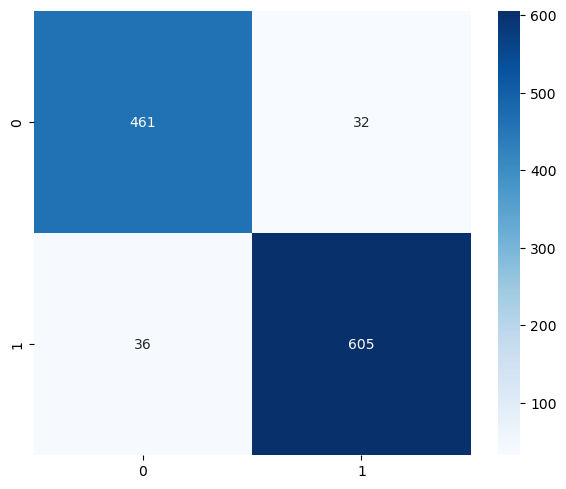

In [77]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()